 ENVIRONMENT SETUP

In [2]:
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.6 MB/s eta 0:00:00


In [3]:
import os
import random
import warnings
from collections import Counter
from pathlib import Path
 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay,
)
from sklearn.preprocessing import label_binarize
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchmetrics
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import wandb
from segmentation_models_pytorch.losses import FocalLoss
 
warnings.filterwarnings("ignore")
print("done")

done


CONFIGURATION  

A centralized class defining hyperparameters: image dimensions ($64 \times 64$), learning rate ($1e-4$), batch size ($16$), and focal loss parameters. It also initializes the random seed for reproducibility.

In [4]:
class CFG:
    SEED: int = 42
    MS_BANDS: int = 5  
    HS_BANDS: int = 124
 
    BASE_PATH: str = "/kaggle/input/competitions/beyond-visible-spectrum-ai-for-agriculture-2026/Kaggle_Prepared/train"
    IMG_H:     int = 64
    IMG_W:     int = 64
 
    LABEL_MAPPING: dict = None   
 
    N_FOLDS:       int   = 5
    EPOCHS:        int   = 50
    BATCH_SIZE:    int   = 16
    LR:            float = 1e-4
    WEIGHT_DECAY:  float = 1e-4
    PATIENCE:      int   = 8     
    GRAD_CLIP:     float = 1.0   
 
    BACKBONE:      str   = "resnet50"
    NUM_CLASSES:   int   = 3    
 
    FOCAL_ALPHA:   float = 0.25
    FOCAL_GAMMA:   float = 2.0
 
    WANDB_PROJECT: str   = "icpr2026-agvision"
    WANDB_ENTITY:  str   = None   
 
    DEVICE: str = "cuda" if torch.cuda.is_available() else "cpu"
    NUM_WORKERS: int = 2
 
 
def seed_everything(seed: int = CFG.SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
 
seed_everything()
print(f"Device: {CFG.DEVICE}")
 

Device: cuda


GOOGLE DRIVE MOUNT + DATA DISCOVERY

Scans the directory structure to locate and count the Hyperspectral (.tif), Multispectral (.tif), and RGB (.png) files, ensuring the dataset is balanced and correctly pathed.

In [5]:
from pathlib import Path

base_path = Path(CFG.BASE_PATH)

hs_files = sorted(list(base_path.rglob('HS/*.tif')))
ms_files = sorted(list(base_path.rglob('MS/*.tif')))
rgb_files = sorted(list(base_path.rglob('RGB/*.png')))

print(f"HS files found: {len(hs_files)}")
print(f"MS files found: {len(ms_files)}")
print(f"RGB files found: {len(rgb_files)}")

if len(hs_files) > 0:
    print(f"First HS file: {hs_files[0]}")

HS files found: 600
MS files found: 600
RGB files found: 600
First HS file: /kaggle/input/competitions/beyond-visible-spectrum-ai-for-agriculture-2026/Kaggle_Prepared/train/HS/Health_hyper_1.tif


DATA LOADING & SANITY CHECKS

Opens a sample from each modality to verify image shapes and data types. It dynamically updates the number of HS bands (125) and creates a mapping for the target classes (Health, Other, Rust).

In [6]:
import tifffile as tiff  
 
sample_hs  = tiff.imread(str(hs_files[0]))
sample_ms  = tiff.imread(str(ms_files[0]))
sample_rgb = np.array(Image.open(str(rgb_files[0])))
 
print(f"\nSingle sample shapes:")
print(f"  HS  : {sample_hs.shape}  dtype={sample_hs.dtype}")
print(f"  MS  : {sample_ms.shape}  dtype={sample_ms.dtype}")
print(f"  RGB : {sample_rgb.shape}  dtype={sample_rgb.dtype}")
 
CFG.HS_BANDS = sample_hs.shape[-1] if sample_hs.ndim == 3 else sample_hs.shape[0]
print(f"\nActual HS bands: {CFG.HS_BANDS}")
 
labels_raw = []
for f in hs_files:
    stem = f.stem   
    label_str = stem.split("_")[0]
    labels_raw.append(label_str)
 
class_counts = Counter(labels_raw)
print(f"\nClass distribution: {dict(class_counts)}")
 
CFG.LABEL_MAPPING = {cls: i for i, cls in enumerate(sorted(class_counts.keys()))}
CFG.NUM_CLASSES   = len(CFG.LABEL_MAPPING)
print(f"Label mapping : {CFG.LABEL_MAPPING}")


Single sample shapes:
  HS  : (32, 32, 125)  dtype=uint16
  MS  : (64, 64, 5)  dtype=uint16
  RGB : (64, 64, 3)  dtype=uint8

Actual HS bands: 125

Class distribution: {'Health': 200, 'Other': 200, 'Rust': 200}
Label mapping : {'Health': 0, 'Other': 1, 'Rust': 2}


PREPROCESSING UTILITIES

Contains logic to normalize data (Z-score normalization for HS/MS) and resize images from different resolutions to a unified size using skimage.

In [7]:
def normalize_array(arr: np.ndarray) -> np.ndarray:
    """Per-band z-score normalisation."""
def normalize_array(arr: np.ndarray) -> np.ndarray:
    """Per-band z-score normalisation."""
    if arr.ndim == 2:
        arr = arr[..., np.newaxis]
    out = np.zeros_like(arr, dtype=np.float32)
    for b in range(arr.shape[-1]):
        band = arr[..., b].astype(np.float32)
        mean, std = band.mean(), band.std()
        out[..., b] = (band - mean) / (std + 1e-8)
    return out
 
def preprocess_sample(idx: int):
    """
    Load, resize, and normalise one multimodal sample.
    Returns (hs_norm, ms_norm, rgb_norm, label_int).
    """
    H, W = CFG.IMG_H, CFG.IMG_W
 
    hs  = tiff.imread(str(hs_files[idx])).astype(np.float32)
    ms  = tiff.imread(str(ms_files[idx])).astype(np.float32)
    rgb = np.array(Image.open(str(rgb_files[idx]))).astype(np.float32)
 
    if hs.ndim == 2:   hs  = hs[..., np.newaxis]
    if ms.ndim == 2:   ms  = ms[..., np.newaxis]
    if rgb.ndim == 2:  rgb = rgb[..., np.newaxis]
 
    from skimage.transform import resize as sk_resize
    hs  = sk_resize(hs,  (H, W, hs.shape[-1]),  preserve_range=True, anti_aliasing=True)
    ms  = sk_resize(ms,  (H, W, ms.shape[-1]),  preserve_range=True, anti_aliasing=True)
    rgb = sk_resize(rgb, (H, W, rgb.shape[-1]), preserve_range=True, anti_aliasing=True)
 
    hs_norm  = normalize_array(hs)
    ms_norm  = normalize_array(ms)
    rgb_norm = (rgb / 255.0).astype(np.float32)   # simple [0,1] for RGB
 
    label_str = hs_files[idx].stem.split("_")[0]
    label     = CFG.LABEL_MAPPING[label_str]
 
    return hs_norm, ms_norm, rgb_norm, label
 
 
hs_s, ms_s, rgb_s, lbl_s = preprocess_sample(0)
print(f"\nSample 0 → HS {hs_s.shape}, MS {ms_s.shape}, RGB {rgb_s.shape}, label {lbl_s}")


Sample 0 → HS (64, 64, 125), MS (64, 64, 5), RGB (64, 64, 3), label 0


 EXPLORATORY DATA ANALYSIS

Visualizes the spectral signatures of hyperspectral data and performs Principal Component Analysis (PCA) to see how much variance is captured in the top spectral bands.

Skipped image 114 - unexpected band count: 32
Skipped image 25 - unexpected band count: 32
Skipped image 281 - unexpected band count: 32
Skipped image 250 - unexpected band count: 32
Skipped image 228 - unexpected band count: 32
Skipped image 142 - unexpected band count: 32
Skipped image 104 - unexpected band count: 32
Skipped image 558 - unexpected band count: 32
Skipped image 89 - unexpected band count: 32
Skipped image 432 - unexpected band count: 32
Skipped image 32 - unexpected band count: 32
Skipped image 30 - unexpected band count: 32
Skipped image 95 - unexpected band count: 32
Skipped image 223 - unexpected band count: 32
Skipped image 238 - unexpected band count: 32
Skipped image 517 - unexpected band count: 32
Skipped image 27 - unexpected band count: 32
Skipped image 574 - unexpected band count: 32
Skipped image 203 - unexpected band count: 32
Skipped image 429 - unexpected band count: 32
Skipped image 225 - unexpected band count: 32
Skipped image 459 - unexpected band coun

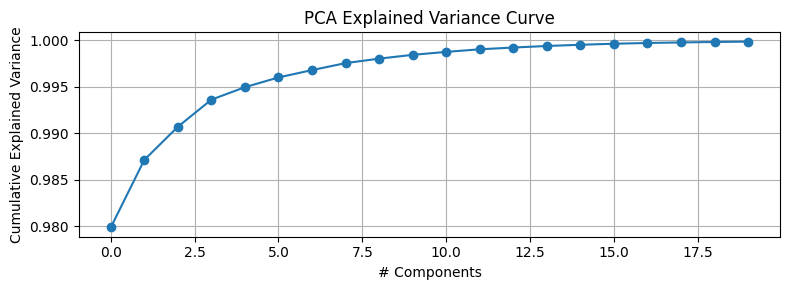

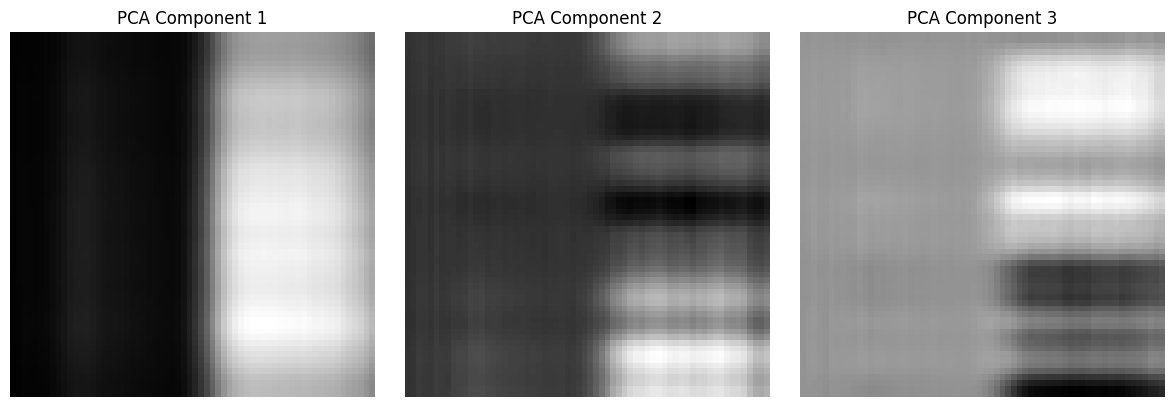

In [8]:
def plot_mean_spectral_signature(n_samples: int = 50):
    indices = random.sample(range(len(hs_files)), min(n_samples, len(hs_files)))
    band_means = []
    
    for i in indices:
        img = tiff.imread(str(hs_files[i])).astype(np.float32)
        
        if img.ndim == 3 and img.shape[0] < img.shape[-1]:
            img = np.moveaxis(img, 0, -1) 
            
        img_mean = img.mean(axis=(0, 1))
        
        if img_mean.shape[0] == 12: 
            band_means.append(img_mean)
        else:
            print(f"Skipped image {i} - unexpected band count: {img_mean.shape[0]}")
            
    if len(band_means) == 0:
        print("Error: No valid images to plot.")
        return
        
    mean_sig = np.mean(band_means, axis=0)
    
    plt.figure(figsize=(12, 4))
    plt.plot(mean_sig)
    plt.title('Mean Spectral Signature Across HS Bands')
    plt.xlabel('Band Index')
    plt.ylabel('Mean Intensity')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_mean_spectral_signature()


def run_pca_analysis(n_components: int = 10, n_samples: int = 100):
    """
    Flatten HS patches → PCA.  Shows cumulative explained variance
    and the first 3 PCA component images.
    """
    indices = random.sample(range(len(hs_files)), min(n_samples, len(hs_files)))
    hs_list = []
    
    for i in indices:
        arr = tiff.imread(str(hs_files[i])).astype(np.float32)
        
        if arr.ndim == 3 and arr.shape[0] < arr.shape[-1]:
            arr = np.moveaxis(arr, 0, -1)
            
        if arr.ndim == 2:
            arr = arr[..., np.newaxis]
            
        from skimage.transform import resize as sk_resize
        arr = sk_resize(arr, (CFG.IMG_H, CFG.IMG_W, arr.shape[-1]),
                        preserve_range=True, anti_aliasing=True)
        hs_list.append(arr)

    hs_stack  = np.stack(hs_list, axis=0)          # (N, H, W, C)
    N, H, W, C = hs_stack.shape
    hs_flat   = hs_stack.reshape(N * H * W, C)

    pca = PCA(n_components=min(n_components, C))
    pca.fit(hs_flat)

    cumvar = np.cumsum(pca.explained_variance_ratio_)
    plt.figure(figsize=(8, 3))
    plt.plot(cumvar, marker='o')
    plt.title("PCA Explained Variance Curve")
    plt.xlabel("# Components")
    plt.ylabel("Cumulative Explained Variance")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    hs0_flat = hs_stack[0].reshape(H * W, C)
    pca_img  = pca.transform(hs0_flat).reshape(H, W, -1)
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    plot_components = min(3, pca_img.shape[-1])
    for k in range(plot_components):
        axes[k].imshow(pca_img[..., k], cmap='gray')
        axes[k].set_title(f"PCA Component {k+1}")
        axes[k].axis("off")
        
    plt.tight_layout()
    plt.show()

    return pca

pca_model = run_pca_analysis(n_components=20, n_samples=50)

AUGMENTATION STRATEGY

Defines the albumentations pipeline for training (flips and rotations). Crucially, it uses additional_targets to ensure that when an RGB image is flipped, the corresponding HS and MS tensors are flipped identically.

In [9]:
def get_augmentation(is_train: bool, img_h: int = CFG.IMG_H, img_w: int = CFG.IMG_W):
    if is_train:
        return A.Compose([
            A.RandomRotate90(p=0.5),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
        ], additional_targets={'hs': 'image', 'ms': 'image'}) 
    else:
        return A.Compose([], additional_targets={'hs': 'image', 'ms': 'image'})
print("done")

done


Multimodal Dataset Class

A custom PyTorch Dataset that loads triplets of images (HS, MS, RGB) for each sample, applies augmentations, and converts them into tensors ready for the GPU.

In [10]:
def convert_to_tensors(hs, ms, rgb, label, target_hs_bands: int = CFG.HS_BANDS):
    hs_t  = torch.tensor(hs,  dtype=torch.float32).permute(2, 0, 1)
    ms_t  = torch.tensor(ms,  dtype=torch.float32).permute(2, 0, 1)
    rgb_t = torch.tensor(rgb, dtype=torch.float32).permute(2, 0, 1)
    lbl_t = torch.tensor(label, dtype=torch.long)
    
    current_bands = hs_t.shape[0]
    if current_bands > target_hs_bands:
        hs_t = hs_t[:target_hs_bands, :, :]
    elif current_bands < target_hs_bands:
        padding = torch.zeros((target_hs_bands - current_bands, hs_t.shape[1], hs_t.shape[2]))
        hs_t = torch.cat([hs_t, padding], dim=0)

    return hs_t, ms_t, rgb_t, lbl_t
 
 
class MultimodalDataset(Dataset):
    def __init__(self, hs_files, ms_files, rgb_files, is_train: bool = True):
        self.hs_files  = hs_files
        self.ms_files  = ms_files
        self.rgb_files = rgb_files
        self.aug       = get_augmentation(is_train)
 
    def __len__(self):
        return len(self.hs_files)
 
    def __getitem__(self, idx):
        hs, ms, rgb, label = preprocess_sample(idx)
 
        if self.aug:
            augmented = self.aug(image=rgb, hs=hs, ms=ms)
            rgb = augmented['image']
            hs = augmented['hs']
            ms = augmented['ms']
 
        hs_t, ms_t, rgb_t, lbl_t = convert_to_tensors(hs, ms, rgb, label)
        return {"hs": hs_t, "ms": ms_t, "rgb": rgb_t, "label": lbl_t}
print("done")

done


MODEL ZOO

Defines four potential architectures:

Baselines: Standard ResNet50 or EfficientNet.

Proposed SEFusionModel: A dual-branch model using ConvNeXt for HS data and EfficientNet for MS+RGB, fused via a Squeeze-and-Excitation (SE) block for feature recalibration.

In [11]:
class SEBlock(nn.Module):
    def __init__(self, channels: int, reduction: int = 16):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc   = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid(),
        )
 
    def forward(self, x):
        b, c, _, _ = x.shape
        s = self.pool(x).view(b, c)
        s = self.fc(s).view(b, c, 1, 1)
        return x * s
 
 
class ResNet50Baseline(nn.Module):
    """
    Standard ResNet-50 with first conv replaced to accept `num_bands` channels.
    Uses only hyperspectral input (no fusion).
    """
    def __init__(self, num_bands: int = CFG.HS_BANDS, num_classes: int = CFG.NUM_CLASSES):
        super().__init__()
        self.model = timm.create_model(
            "resnet50", pretrained=True,
            in_chans=num_bands,
            num_classes=num_classes,
        )
 
    def forward(self, batch):
        return self.model(batch["hs"])
 
 
class EfficientNetBaseline(nn.Module):
    """
    EfficientNet-B2 receiving concatenated MS + RGB (ms_bands + 3 channels).
    """
    def __init__(self, ms_bands: int = CFG.MS_BANDS, num_classes: int = CFG.NUM_CLASSES):
        super().__init__()
        in_chans = ms_bands + 3
        self.model = timm.create_model(
            "efficientnet_b2", pretrained=True,
            in_chans=in_chans,
            num_classes=num_classes,
        )
 
    def forward(self, batch):
        x = torch.cat([batch["ms"], batch["rgb"]], dim=1)
        return self.model(x)
 
 
class SEFusionModel(nn.Module):
    """
    Novel contribution:
      - Branch A: ConvNeXt-Small backbone on HS (full spectral input)
      - Branch B: EfficientNet-B2 backbone on MS+RGB
      - SE-weighted feature fusion before classification head
    This is your 'go-beyond-baseline' model.
    """
    def __init__(
        self,
        hs_bands:    int = CFG.HS_BANDS,
        ms_bands:    int = CFG.MS_BANDS,
        num_classes: int = CFG.NUM_CLASSES,
        embed_dim:   int = 512,
    ):
        super().__init__()
 
        self.hs_backbone = timm.create_model(
            "convnext_small", pretrained=True,
            in_chans=hs_bands, num_classes=0,   
            global_pool="avg",
        )
        hs_feat_dim = self.hs_backbone.num_features
 
        self.ms_backbone = timm.create_model(
            "efficientnet_b2", pretrained=True,
            in_chans=ms_bands + 3, num_classes=0,
            global_pool="avg",
        )
        ms_feat_dim = self.ms_backbone.num_features
 
        self.hs_proj = nn.Sequential(
            nn.Linear(hs_feat_dim, embed_dim),
            nn.GELU(),
            nn.LayerNorm(embed_dim),
        )
        self.ms_proj = nn.Sequential(
            nn.Linear(ms_feat_dim, embed_dim),
            nn.GELU(),
            nn.LayerNorm(embed_dim),
        )
 
        self.se = SEBlock(2 * embed_dim, reduction=16)
 
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(2 * embed_dim, 256),
            nn.GELU(),
            nn.Dropout(p=0.3),
            nn.Linear(256, num_classes),
        )
 
    def forward(self, batch):
        hs_feat = self.hs_backbone(batch["hs"])         
        ms_feat = self.ms_backbone(
            torch.cat([batch["ms"], batch["rgb"]], dim=1)
        )                                                
 
        hs_emb = self.hs_proj(hs_feat)                  
        ms_emb = self.ms_proj(ms_feat)                 
 
        fused = torch.cat([hs_emb, ms_emb], dim=1)      
 
        fused_4d = fused.unsqueeze(-1).unsqueeze(-1)    # (B, 2E, 1, 1)
        fused_se = self.se(fused_4d).squeeze(-1).squeeze(-1)
 
        logits = self.classifier(fused_se)
        return logits
class NoSEFusionModel(nn.Module):
    
    
    def __init__(
        self,
        hs_bands:    int = CFG.HS_BANDS,
        ms_bands:    int = CFG.MS_BANDS,
        num_classes: int = CFG.NUM_CLASSES,
        embed_dim:   int = 512,
    ):
        super().__init__()
        
        self.hs_backbone = timm.create_model(
            "convnext_small", pretrained=True,
            in_chans=hs_bands, num_classes=0, global_pool="avg",
        )
        hs_feat_dim = self.hs_backbone.num_features
 
        self.ms_backbone = timm.create_model(
            "efficientnet_b2", pretrained=True,
            in_chans=ms_bands + 3, num_classes=0, global_pool="avg",
        )
        ms_feat_dim = self.ms_backbone.num_features
 
        self.hs_proj = nn.Sequential(
            nn.Linear(hs_feat_dim, embed_dim), nn.GELU(), nn.LayerNorm(embed_dim),
        )
        self.ms_proj = nn.Sequential(
            nn.Linear(ms_feat_dim, embed_dim), nn.GELU(), nn.LayerNorm(embed_dim),
        )
 
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(2 * embed_dim, 256),
            nn.GELU(),
            nn.Dropout(p=0.3),
            nn.Linear(256, num_classes),
        )
 
    def forward(self, batch):
        hs_feat = self.hs_backbone(batch["hs"])         
        ms_feat = self.ms_backbone(
            torch.cat([batch["ms"], batch["rgb"]], dim=1)
        )                                                
 
        hs_emb = self.hs_proj(hs_feat)                  
        ms_emb = self.ms_proj(ms_feat)                  
 
        fused = torch.cat([hs_emb, ms_emb], dim=1)      
 
        logits = self.classifier(fused)
        return logits
 
def build_model(name: str = "proposed") -> nn.Module:
    if name == "resnet50":
        return ResNet50Baseline()
    elif name == "efficientnet":
        return EfficientNetBaseline()
    elif name == "proposed" or name == "no_focal_loss":
        return SEFusionModel()
    elif name == "no_se":
        return NoSEFusionModel()
    else:
        raise ValueError(f"Unknown model: {name}")
print("done")

done


 LOSS FUNCTION

Initializes Focal Loss. This is superior to standard Cross-Entropy for this task as it down-weights well-classified examples and focuses training on "hard" samples (e.g., distinguishing between similar plant stresses). 

In [12]:
criterion = FocalLoss(
    mode="multiclass",
    alpha=CFG.FOCAL_ALPHA,
    gamma=CFG.FOCAL_GAMMA,
)
print("Focal Loss criterion: ready")


Focal Loss criterion: ready


OPTIMISER + LR SCHEDULER

Sets up a OneCycleLR scheduler for faster convergence. It uses differential learning rates: the pre-trained "backbones" learn slowly, while the custom "fusion head" learns faster.

In [13]:
def build_optimizer(model: nn.Module):
    backbone_params, head_params = [], []
    for name, param in model.named_parameters():
        if "classifier" in name or "proj" in name or "se" in name:
            head_params.append(param)
        else:
            backbone_params.append(param)
    optimizer = torch.optim.AdamW([
        {"params": backbone_params, "lr": CFG.LR / 10},
        {"params": head_params,     "lr": CFG.LR},
    ], weight_decay=CFG.WEIGHT_DECAY)
    return optimizer


def build_scheduler(optimizer, steps_per_epoch: int):
    return torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=[CFG.LR / 10, CFG.LR],
        steps_per_epoch=steps_per_epoch,
        epochs=CFG.EPOCHS,
        pct_start=0.1,
    )
print("done")

done


WEIGHTS & BIASES INITIALISATION

A helper function to initialize experiment tracking, allowing you to monitor loss curves and hardware usage in real-time (set to offline by default in this notebook).

In [14]:
def init_wandb(fold: int, model_name: str):
    wandb.init(
        project=CFG.WANDB_PROJECT,
        entity=CFG.WANDB_ENTITY,
        name=f"{model_name}_fold{fold}",
        config={
            "backbone":    CFG.BACKBONE,
            "epochs":      CFG.EPOCHS,
            "batch_size":  CFG.BATCH_SIZE,
            "lr":          CFG.LR,
            "n_folds":     CFG.N_FOLDS,
            "hs_bands":    CFG.HS_BANDS,
            "num_classes": CFG.NUM_CLASSES,
            "focal_gamma": CFG.FOCAL_GAMMA,
        },
        reinit=True,
    )
print("done")

done


TRAINING LOOP

Implements Stratified 5-Fold Cross-Validation. This ensures the model is evaluated on every piece of data and that the class distribution remains consistent across all folds.

In [15]:
def run_cross_validation(model_name: str = "proposed", use_wandb: bool = True):
    all_indices  = np.arange(len(hs_files))
    all_labels   = np.array([
        CFG.LABEL_MAPPING[f.stem.split("_")[0]] for f in hs_files
    ])

    skf = StratifiedKFold(n_splits=CFG.N_FOLDS, shuffle=True, random_state=CFG.SEED)

    fold_results = []
    all_models   = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(all_indices, all_labels)):
        model, history, preds, labels, probs = run_fold(
            fold, train_idx, val_idx,
            model_name=model_name,
            use_wandb=use_wandb,
        )
        fold_results.append({"fold": fold, "preds": preds,
                              "labels": labels, "probs": probs,
                              "history": history})
        all_models.append(model)

    print(f"\n{'='*60}")
    print(f"  CROSS-VALIDATION SUMMARY  ({model_name})")
    print(f"{'='*60}")
    for r in fold_results:
        acc = (r["preds"] == r["labels"]).mean()
        print(f"  Fold {r['fold']+1}: acc={acc:.4f}")

    return fold_results, all_models
print("done")

done


5-FOLD STRATIFIED CROSS-VALIDATION

Contains the core train_one_epoch and evaluate functions. It includes Early Stopping to prevent overfitting if the validation loss stops improving for 8 consecutive epochs.

In [21]:
def train_one_epoch(model, loader, optimizer, scheduler, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        batch = {k: v.to(CFG.DEVICE) for k, v in batch.items()}
        labels = batch["label"]

        optimizer.zero_grad()
        logits = model(batch)
        loss   = criterion(logits, labels) 
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), CFG.GRAD_CLIP)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item() * labels.size(0)
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    for batch in loader:
        batch  = {k: v.to(CFG.DEVICE) for k, v in batch.items()}
        labels = batch["label"]
        logits = model(batch)
        loss   = criterion(logits, labels)

        probs  = F.softmax(logits, dim=1)
        preds  = probs.argmax(dim=1)

        total_loss += loss.item() * labels.size(0)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy, np.array(all_preds), np.array(all_labels), np.array(all_probs)


def run_fold(
    fold:       int,
    train_idx:  np.ndarray,
    val_idx:    np.ndarray,
    model_name: str = "proposed",
    use_wandb:  bool = True,
):
    print(f"\n{'='*60}")
    print(f"  FOLD {fold+1} / {CFG.N_FOLDS}  |  model={model_name}")
    print(f"{'='*60}")

    hs_train  = [hs_files[i]  for i in train_idx]
    ms_train  = [ms_files[i]  for i in train_idx]
    rgb_train = [rgb_files[i] for i in train_idx]
    hs_val    = [hs_files[i]  for i in val_idx]
    ms_val    = [ms_files[i]  for i in val_idx]
    rgb_val   = [rgb_files[i] for i in val_idx]

    train_ds = MultimodalDataset(hs_train, ms_train, rgb_train, is_train=True)
    val_ds   = MultimodalDataset(hs_val,   ms_val,   rgb_val,   is_train=False)

    train_labels = [CFG.LABEL_MAPPING[f.stem.split("_")[0]] for f in hs_train]
    class_weights = {c: 1.0 / cnt for c, cnt in Counter(train_labels).items()}
    sample_weights = [class_weights[l] for l in train_labels]
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(train_ds), replacement=True)

    train_loader = DataLoader(train_ds, batch_size=CFG.BATCH_SIZE,
                              sampler=sampler, num_workers=CFG.NUM_WORKERS,
                              pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=CFG.BATCH_SIZE,
                              shuffle=False, num_workers=CFG.NUM_WORKERS,
                              pin_memory=True)

    model     = build_model(model_name).to(CFG.DEVICE)
    optimizer = build_optimizer(model)
    scheduler = build_scheduler(optimizer, len(train_loader))

    if model_name == "no_focal_loss":
        fold_criterion = nn.CrossEntropyLoss()
    else:
        fold_criterion = FocalLoss(
            mode="multiclass",
            alpha=CFG.FOCAL_ALPHA,
            gamma=CFG.FOCAL_GAMMA,
        )

    if use_wandb:
        init_wandb(fold, model_name)

    best_val_loss  = float("inf")
    patience_count = 0
    best_model_state = None
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(CFG.EPOCHS):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, scheduler, fold_criterion)
        val_loss, val_acc, _, _, _ = evaluate(model, val_loader, fold_criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if use_wandb:
            wandb.log({
                "epoch": epoch + 1,
                "train_loss": train_loss,
                "train_acc":  train_acc,
                "val_loss":   val_loss,
                "val_acc":    val_acc,
                "lr_backbone": optimizer.param_groups[0]["lr"],
                "lr_head":     optimizer.param_groups[1]["lr"],
            })

        print(f"  Ep {epoch+1:3d}/{CFG.EPOCHS} | "
              f"TL={train_loss:.4f} TA={train_acc:.4f} | "
              f"VL={val_loss:.4f} VA={val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            patience_count   = 0
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_count += 1
            if patience_count >= CFG.PATIENCE:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_model_state)
    
    _, val_acc, preds, labels, probs = evaluate(model, val_loader, fold_criterion)

    print(f"\n  Fold {fold+1} best val_acc = {val_acc:.4f}")
    
    # 1. Safely flatten to ensure 1D arrays
    y_true_flat = np.array(labels).flatten()
    y_pred_flat = np.array(preds).flatten()
    
    # 2. Pass 'labels' argument to force Sklearn to check against all mapped classes
    print(classification_report(y_true_flat, y_pred_flat,
                                 labels=list(CFG.LABEL_MAPPING.values()), 
                                 target_names=list(CFG.LABEL_MAPPING.keys())))

    if use_wandb:
        wandb.finish()

    return model, history, preds, labels, probs
print("done")

done


EVALUATION UTILITIES

Generates visual performance reports, including the Confusion Matrix and ROC-AUC scores, to understand which specific classes the model might be confusing.

In [22]:
def full_evaluation(preds, labels, probs, class_names=None):
    """Per-class metrics, confusion matrix, ROC-AUC."""
    if class_names is None:
        class_names = list(CFG.LABEL_MAPPING.keys())

    # Safely convert to 1D arrays
    y_true_flat = np.array(labels).flatten()
    y_pred_flat = np.array(preds).flatten()

    print("\n── Classification Report ──")
    print(classification_report(y_true_flat, y_pred_flat, 
                                labels=list(CFG.LABEL_MAPPING.values()), 
                                target_names=class_names))

    cm = confusion_matrix(y_true_flat, y_pred_flat, labels=list(CFG.LABEL_MAPPING.values()))
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

    n_classes = CFG.NUM_CLASSES
    lb = label_binarize(y_true_flat, classes=list(range(n_classes)))
    if n_classes == 2:
        auc = roc_auc_score(lb, probs[:, 1])
        print(f"ROC-AUC (binary): {auc:.4f}")
    else:
        auc = roc_auc_score(lb, probs, multi_class="ovr", average="macro")
        print(f"ROC-AUC (macro OvR): {auc:.4f}")


def plot_training_curves(history: dict, fold: int = 0):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["train_loss"], label="Train Loss")
    axes[0].plot(history["val_loss"],   label="Val Loss")
    axes[0].set_title(f"Fold {fold+1} — Loss")
    axes[0].legend(); axes[0].grid(True)

    axes[1].plot(history["val_acc"], label="Val Acc", color="green")
    axes[1].set_title(f"Fold {fold+1} — Val Accuracy")
    axes[1].legend(); axes[1].grid(True)
    plt.tight_layout()
    plt.show()
print("done")

done


ABLATION STUDY HELPER

A specialized function to systematically "turn off" features (like the SE block or Focal Loss) to prove exactly which component provides the most performance boost.

In [23]:
def run_ablation():
    
    all_indices = np.arange(len(hs_files))
    all_labels  = np.array([
        CFG.LABEL_MAPPING[f.stem.split("_")[0]] for f in hs_files
    ])
    skf = StratifiedKFold(n_splits=CFG.N_FOLDS, shuffle=True, random_state=CFG.SEED)
    train_idx, val_idx = next(iter(skf.split(all_indices, all_labels)))

    results = {}
    
    variants = ["proposed", "no_se", "no_focal_loss"]
    
    for name in variants:
        print(f"\n[ABLATION] Variant: {name}")
        _, history, preds, labels, _ = run_fold(
            fold=0, train_idx=train_idx, val_idx=val_idx,
            model_name=name, use_wandb=False,
        )
        acc = (preds == labels).mean()
        results[name] = acc
        print(f"  → val_acc = {acc:.4f}")

    print("\n── Ablation Summary ──")
    for name, acc in results.items():
        print(f"  {name:20s}: {acc:.4f}")
    return results
print("done")

done


INFERENCE / SUBMISSION

The entry point that triggers the training process, plots the final results, and provides a utility to generate a submission.csv for competition purposes.


  FOLD 1 / 5  |  model=proposed


  Ep   1/50 | TL=0.2704 TA=0.4021 | VL=0.2110 VA=0.9500
  Ep   2/50 | TL=0.2087 TA=0.4521 | VL=0.1627 VA=0.6833
  Ep   3/50 | TL=0.1734 TA=0.5625 | VL=0.1208 VA=0.8917
  Ep   4/50 | TL=0.1578 TA=0.6229 | VL=0.1745 VA=0.7000
  Ep   5/50 | TL=0.1690 TA=0.5563 | VL=0.1468 VA=0.8583
  Ep   6/50 | TL=0.1474 TA=0.6771 | VL=0.1576 VA=0.7417
  Ep   7/50 | TL=0.1452 TA=0.6417 | VL=0.1570 VA=0.7917
  Ep   8/50 | TL=0.1307 TA=0.7042 | VL=0.1737 VA=0.6833
  Ep   9/50 | TL=0.1311 TA=0.7021 | VL=0.0939 VA=0.9167
  Ep  10/50 | TL=0.1310 TA=0.7104 | VL=0.1106 VA=0.9000
  Ep  11/50 | TL=0.1218 TA=0.7312 | VL=0.1048 VA=0.8417
  Ep  12/50 | TL=0.1167 TA=0.7562 | VL=0.1042 VA=0.8750
  Ep  13/50 | TL=0.1193 TA=0.7354 | VL=0.0732 VA=0.8917
  Ep  14/50 | TL=0.1100 TA=0.7500 | VL=0.0515 VA=0.9417
  Ep  15/50 | TL=0.1161 TA=0.7583 | VL=0.0648 VA=0.9167
  Ep  16/50 | TL=0.0915 TA=0.8208 | VL=0.0689 VA=0.8417
  Ep  17/50 | TL=0.1052 TA=0.7937 | VL=0.1067 VA=0.7583
  Ep  18/50 | TL=0.0820 TA=0.8583 | VL=0.0625 VA

epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇██
lr_backbone,▁▃▅▇████████▇▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▁▁
lr_head,▁▃▅▇████████▇▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▁▁
train_acc,▁▂▃▄▃▄▄▅▅▅▅▅▅▅▅▆▆▇▆▇▇▇▇▇▇▇█▇████████████
train_loss,█▆▅▅▅▅▅▄▄▄▄▄▄▄▄▃▃▃▃▂▂▂▂▂▂▂▁▂▂▁▂▂▁▂▁▂▁▂▁▁
val_acc,▇▁▆▁▅▂▃▁▆▆▅▅▆▇▆▅▃▆██▆▇▇▇▇▇▇▆▇▇▇▇▇▇▇▇▇▇▇▇
val_loss,█▆▅▇▆▆▆▇▄▄▄▄▃▂▃▃▄▃▂▁▃▂▂▂▁▁▂▂▁▁▁▁▁▁▂▁▂▂▁▁
epoch,41
lr_backbone,0.0
lr_head,1e-05
train_acc,0.97917



  FOLD 2 / 5  |  model=proposed


  Ep   1/50 | TL=0.2940 TA=0.3250 | VL=0.2583 VA=0.4000
  Ep   2/50 | TL=0.2170 TA=0.4208 | VL=0.1595 VA=0.8250
  Ep   3/50 | TL=0.1703 TA=0.5833 | VL=0.1400 VA=0.7917
  Ep   4/50 | TL=0.1597 TA=0.6146 | VL=0.1326 VA=0.8417
  Ep   5/50 | TL=0.1576 TA=0.6042 | VL=0.1432 VA=0.8917
  Ep   6/50 | TL=0.1444 TA=0.6708 | VL=0.1673 VA=0.7333
  Ep   7/50 | TL=0.1401 TA=0.6792 | VL=0.1067 VA=0.8833
  Ep   8/50 | TL=0.1365 TA=0.6708 | VL=0.1392 VA=0.7833
  Ep   9/50 | TL=0.1367 TA=0.6667 | VL=0.1104 VA=0.8833
  Ep  10/50 | TL=0.1245 TA=0.6979 | VL=0.1587 VA=0.7667
  Ep  11/50 | TL=0.1322 TA=0.7125 | VL=0.0982 VA=0.9000
  Ep  12/50 | TL=0.1203 TA=0.7479 | VL=0.0880 VA=0.8917
  Ep  13/50 | TL=0.1051 TA=0.7729 | VL=0.0728 VA=0.9250
  Ep  14/50 | TL=0.1129 TA=0.7583 | VL=0.0669 VA=0.9583
  Ep  15/50 | TL=0.1061 TA=0.7562 | VL=0.1116 VA=0.7833
  Ep  16/50 | TL=0.0989 TA=0.7625 | VL=0.1329 VA=0.6583
  Ep  17/50 | TL=0.0907 TA=0.8271 | VL=0.0716 VA=0.8750
  Ep  18/50 | TL=0.0767 TA=0.8604 | VL=0.0315 VA

...

epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
lr_backbone,▂▄▆██████▇▇▇▇▇▆▆▆▆▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁
lr_head,▂▄▆▇██████▇▇▇▇▇▆▆▆▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁
train_acc,▁▁▃▄▄▄▅▅▄▅▅▅▆▆▆▇▇▇▇▇▇██▇████████████████
train_loss,█▆▅▅▄▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▂▁▁▁
val_acc,▆▃▆▆▃▇▁▁▄▅▅▅▅▆▆▇▅▇▆▇▇█▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇
val_loss,█▆▆▅▆▄▆█▆▄▄▄▃▃▃▂▃▂▂▂▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,50
lr_backbone,0.0
lr_head,0.0
train_acc,0.95833



  FOLD 5 / 5  |  model=proposed


  Ep   1/50 | TL=0.2751 TA=0.3417 | VL=0.2294 VA=0.5917
  Ep   2/50 | TL=0.2070 TA=0.4646 | VL=0.1617 VA=0.6667
  Ep   3/50 | TL=0.1727 TA=0.5792 | VL=0.1380 VA=0.8250
  Ep   4/50 | TL=0.1612 TA=0.6167 | VL=0.1481 VA=0.7750
  Ep   5/50 | TL=0.1656 TA=0.5437 | VL=0.1533 VA=0.7667
  Ep   6/50 | TL=0.1610 TA=0.6000 | VL=0.2558 VA=0.1833
  Ep   7/50 | TL=0.1484 TA=0.6667 | VL=0.1045 VA=0.9167
  Ep   8/50 | TL=0.1470 TA=0.6458 | VL=0.1142 VA=0.9417
  Ep   9/50 | TL=0.1365 TA=0.7083 | VL=0.1943 VA=0.5083
  Ep  10/50 | TL=0.1427 TA=0.6479 | VL=0.1031 VA=0.9333
  Ep  11/50 | TL=0.1309 TA=0.7229 | VL=0.1431 VA=0.6917
  Ep  12/50 | TL=0.1306 TA=0.7167 | VL=0.1080 VA=0.8667
  Ep  13/50 | TL=0.1257 TA=0.7292 | VL=0.1299 VA=0.7667
  Ep  14/50 | TL=0.1193 TA=0.7396 | VL=0.1027 VA=0.8250
  Ep  15/50 | TL=0.1096 TA=0.7729 | VL=0.0877 VA=0.8833
  Ep  16/50 | TL=0.1152 TA=0.7396 | VL=0.0660 VA=0.9167
  Ep  17/50 | TL=0.0949 TA=0.7958 | VL=0.0539 VA=0.9083
  Ep  18/50 | TL=0.0867 TA=0.8479 | VL=0.0735 VA

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
lr_backbone,▂▄▆▇██████▇▇▇▇▇▆▆▆▆▆▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁▁
lr_head,▂▄▆▇██████▇▇▇▇▇▆▆▆▆▅▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁
train_acc,▁▄▄▃▄▄▅▄▅▅▅▆▅▆▇▆▇▇▇▇▇▇█▇▇▇██████████████
train_loss,█▆▅▅▅▅▅▄▄▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▂▁▁
val_acc,▅▅▇▆▁█▄▇▅▇▇▇▇▇▇▇▇▇▇▇██▇█▇▇▇██▇██████████
val_loss,█▆▅▅▆▄▄▇▄▅▄▄▃▂▃▂▃▃▃▃▂▁▃▂▂▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁
epoch,50
lr_backbone,0.0
lr_head,0.0
train_acc,0.96875



  CROSS-VALIDATION SUMMARY  (proposed)
  Fold 1: acc=0.9583
  Fold 2: acc=1.0000
  Fold 3: acc=1.0000
  Fold 4: acc=0.9583
  Fold 5: acc=0.9917


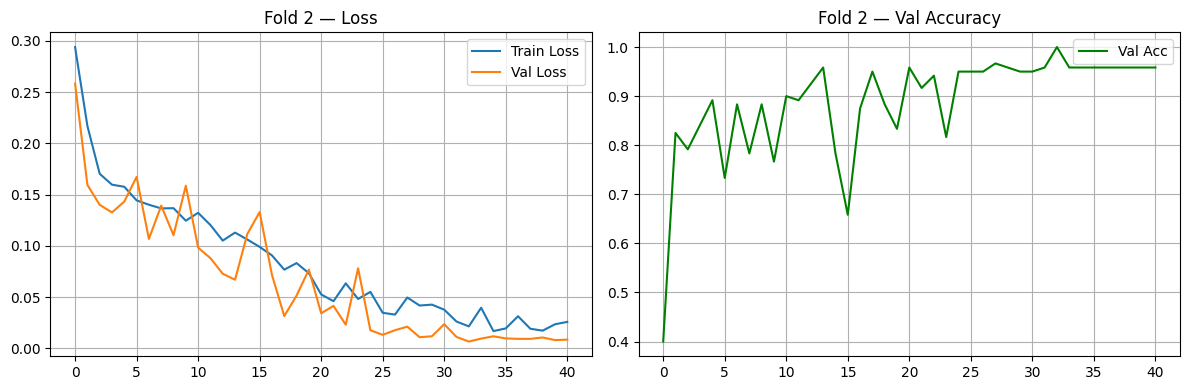


── Classification Report ──
              precision    recall  f1-score   support

      Health       1.00      1.00      1.00       120
       Other       0.00      0.00      0.00         0
        Rust       0.00      0.00      0.00         0

    accuracy                           1.00       120
   macro avg       0.33      0.33      0.33       120
weighted avg       1.00      1.00      1.00       120



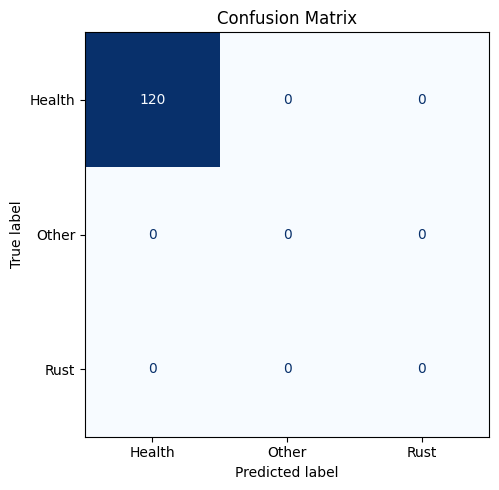

ROC-AUC (macro OvR): nan


In [24]:
def ensemble_predict(models, test_hs, test_ms, test_rgb):
    
    test_ds     = MultimodalDataset(test_hs, test_ms, test_rgb, is_train=False)
    test_loader = DataLoader(test_ds, batch_size=CFG.BATCH_SIZE,
                             shuffle=False, num_workers=CFG.NUM_WORKERS)
 
    all_probs = []
    for model in models:
        model.eval()
        fold_probs = []
        with torch.no_grad():
            for batch in test_loader:
                batch = {k: v.to(CFG.DEVICE) for k, v in batch.items()}
                logits = model(batch)
                probs  = F.softmax(logits, dim=1).cpu().numpy()
                fold_probs.append(probs)
        all_probs.append(np.vstack(fold_probs))
 
    avg_probs = np.mean(all_probs, axis=0)   # (N, num_classes)
    preds     = avg_probs.argmax(axis=1)
 
    inv_map   = {v: k for k, v in CFG.LABEL_MAPPING.items()}
    pred_labels = [inv_map[p] for p in preds]
    return pred_labels, avg_probs
 
 
def generate_submission(models, test_path: str, out_csv: str = "submission.csv"):
    import pandas as pd
    test_base = Path(test_path)
    t_hs  = sorted((test_base / "hs").glob("*.tiff"))
    t_ms  = sorted((test_base / "ms").glob("*.tiff"))
    t_rgb = sorted((test_base / "rgb").glob("*.png"))
 
    pred_labels, _ = ensemble_predict(models, t_hs, t_ms, t_rgb)
    df = pd.DataFrame({"filename": [f.name for f in t_hs], "label": pred_labels})
    df.to_csv(out_csv, index=False)
    print(f"Submission saved to {out_csv}")
    return df
 
 


if __name__ == "__main__":
 
 
    fold_results, trained_models = run_cross_validation(
        model_name="proposed",
        use_wandb=True,   
    )
 
    best_fold = max(fold_results, key=lambda r: (r["preds"] == r["labels"]).mean())
    plot_training_curves(best_fold["history"], fold=best_fold["fold"])
    full_evaluation(best_fold["preds"], best_fold["labels"], best_fold["probs"])
 